# Figure 3: Dynamics of decision parameters across action costs.

## setup and imports

In [1]:
import fnmatch
import matplotlib.pyplot as plt
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *

plt.style.use('./Figures/paper.mplstyle')

In [2]:
# Define folder with data
root = "/home/thomas/Desktop/ALLDATA"

print("Path to data is: %s"%root)
print(f'Found {len(glob.glob(root+"/*"))} rats in the data folder')

Path to data is: /home/thomas/Desktop/ALLDATA
Found 34 rats in the data folder


In [3]:
rat_markers = {}
sequence = {}

# INTACT RATS
animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
            'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 'RatM53', 'RatM54']


m, f = 0, 0
male_palette = create_teal_palette(num_shades=len([x for x in animalList if 'M' in x]))
female_palette = create_blue_violet_palette(num_shades=len([x for x in animalList if 'F' in x]), start_intensity=80)

for index, animal in enumerate(animalList):
    print(f'Loading data for {animal}')
    # define marker and color for each rat, used in plots
    if fnmatch.fnmatch(animal, 'RatF*'):
        rat_markers[animal]=[female_palette[f], 'o', '-']
        f += 1
    elif fnmatch.fnmatch(animal, 'RatM*'):
        rat_markers[animal]=[male_palette[m], 'o', '-']
        m += 1
    elif fnmatch.fnmatch(animal, 'Rat00*'):
        rat_markers[animal]=[(0.0, 0.0, 0.0), "$\u2426$",]
    else:
        print("error, this is not a rat you got here")

    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal[0:6], session, name="sequence.p")

Loading data for RatF00
Loading data for RatF01
Loading data for RatF02
Loading data for RatM00
Loading data for RatM01
Loading data for RatM02
Loading data for RatF32
Loading data for RatF33
Loading data for RatM31
Loading data for RatM32
Loading data for RatF42
Loading data for RatM40
Loading data for RatM43
Loading data for RatM53
Loading data for RatM54


# Figure 3A Schematics of three action cost conditions with increasing platform distances.
# Figure 3D Same with treadmill velocity.

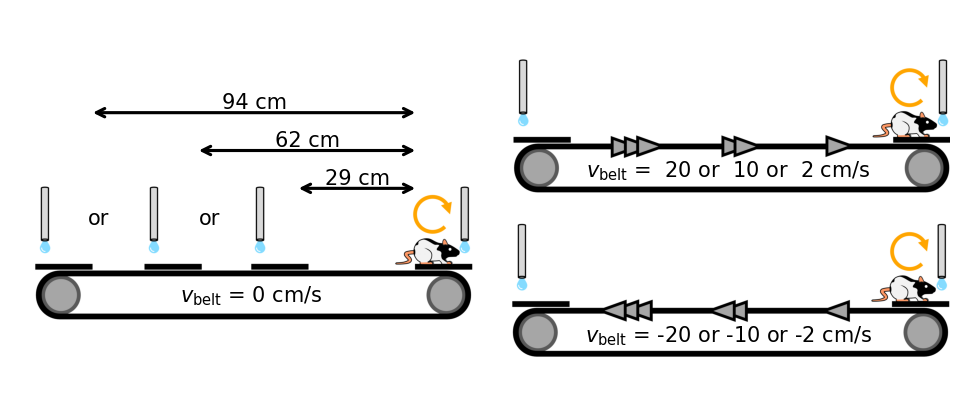

In [4]:
def Figure3A(ax=None, path=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    if path is None:
        path = "./Figures/3Aidle.png"

    img = plt.imread(path)
    img = img[300:2600, 150:3075]
    img = np.concatenate((np.ones((300, img.shape[1], 3), dtype=np.uint8), img), axis=0)
    
    ax.imshow(img)
    ax.axis("off")
    ax.text(s=r'$v_{\mathrm{belt}}$ = 0 cm/s', x=img.shape[1]/2, y=1760, ha="center", va="center", fontsize=5)
    ax.text(s='or', x=450, y=1250, ha="center", va="center", fontsize=5)
    ax.text(s='or', x=1185, y=1250, ha="center", va="center", fontsize=5)

    ax.annotate(text='', xy=(1720, 1050), xytext=(2600, 1050), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    ax.annotate(text='', xy=(1060, 800), xytext=(2600, 800), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    ax.annotate(text='', xy=(360, 550), xytext=(2600, 550), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    
    ax.annotate(text='29 cm', xy=(0, 0), xytext=((1720+2600)/2, 1050), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)
    ax.annotate(text='62 cm', xy=(0, 0), xytext=((1060+2600)/2, 800), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)
    ax.annotate(text='94 cm', xy=(0, 0), xytext=((360+2600)/2, 550), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)

def Figure3D(ax=None, path=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    if path is None:
        path = "./Figures/3Didle.png"

    img = plt.imread(path)
    img = img[:, 150:3075]
    ax.imshow(img)
    ax.axis("off")
    ax.text(s=r'$v_{\mathrm{belt}}$ =  20 or  10 or  2 cm/s', x=img.shape[1]/2, y=930, ha="center", va="center", fontsize=5)
    ax.text(s=r'$v_{\mathrm{belt}}$ = -20 or -10 or -2 cm/s', x=img.shape[1]/2, y=2020, ha="center", va="center", fontsize=5)

fig, axs = plt.subplots(1, 2, figsize=(cm2inch(8), cm2inch(4)))
Figure3A(ax=axs[0])
Figure3D(ax=axs[1])

# 3B Effect of distance on α0, αt and αu
# 3C Effect of distance on γ0, γt and γu

$\alpha_0$: p_s=0.896, p_i=0.000, obs_slope=0.008, obs_intercept=1.153
$\alpha_t$: p_s=0.106, p_i=0.000, obs_slope=-0.022, obs_intercept=0.194
$\alpha_u$: p_s=0.425, p_i=0.580, obs_slope=0.017, obs_intercept=-0.013
$\gamma_0$: p_s=0.839, p_i=0.000, obs_slope=-0.011, obs_intercept=0.739
$\gamma_t$: p_s=0.654, p_i=0.000, obs_slope=0.002, obs_intercept=-0.046
$\gamma_u$: p_s=0.923, p_i=0.000, obs_slope=0.002, obs_intercept=-0.156


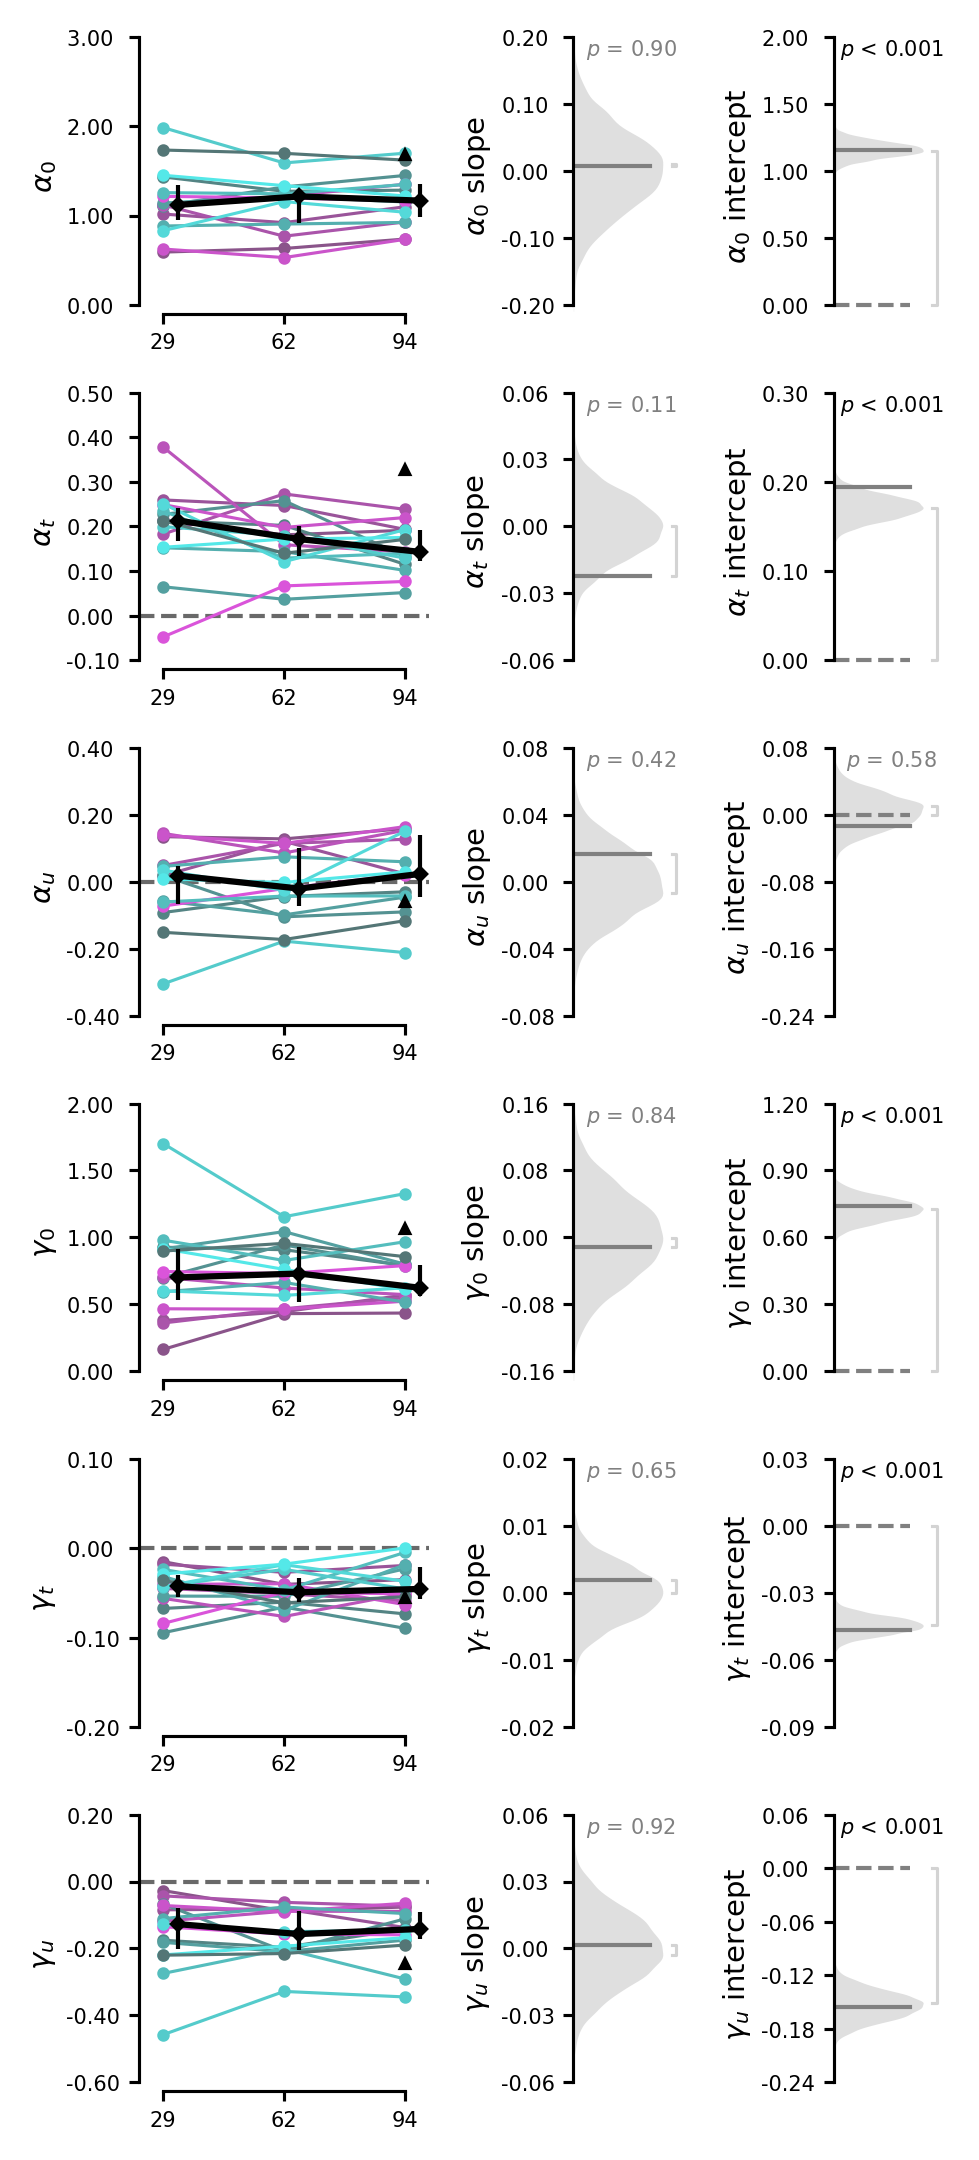

In [5]:
def Figure3B_zero(ax=None, show_xlabel=False):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

    for animal in animalList:
        ax.plot([0, 1, 2], [alpha_0[animal]["60"], alpha_0[animal]["90"], alpha_0[animal]["120"]], 
                        color=rat_markers[animal][0], marker=rat_markers[animal][1], lw=.75,
                        markersize=2, linestyle=rat_markers[animal][2], zorder=8 if animal=='RatM00' else 5)
        
   
    ex_alpha, ex_alpha_t, ex_alpha_u, ex_gamma, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
    ax.plot(2, ex_alpha, color='black', marker='^', zorder=10, markersize=2, linewidth=0, label='Example session')
    
    
    ax.set_xlim(0, 2)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["29", "62", "94"])
    if show_xlabel:
        ax.set_xlabel(r"$d$ (cm)")

    ax.set_ylim(0, 3)
    ax.set_yticks([0, 1, 2, 3])
    ax.set_ylabel(r'$\alpha_0$')
    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(alpha_0, ax=ax, dist_or_tm='dist', animalList=animalList, err='percentile')

def Figure3B_t(ax=None, show_xlabel=False):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

    for animal in animalList:
        ax.plot([0, 1, 2], [alpha_t[animal]["60"], alpha_t[animal]["90"], alpha_t[animal]["120"]], 
                        color=rat_markers[animal][0], label=animal, marker=rat_markers[animal][1], lw=.75,
                        markersize=2, linestyle=rat_markers[animal][2], zorder=8 if animal=='RatM00' else 5)

    ex_alpha, ex_alpha_t, ex_alpha_u, ex_gamma, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
    ax.plot(2, ex_alpha_t, color='black', marker='^', zorder=10, markersize=2, linewidth=0)
    

    ax.set_xlim(0, 2)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["29", "62", "94"])
    if show_xlabel:
        ax.set_xlabel(r"$d$ (cm)")

    ax.set_ylim(-.1, .5)
    ax.set_yticks([-.1, 0, .1, .2, .3, .4, .5])
    ax.set_ylabel(r'$\alpha_t$')

    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0)
    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(alpha_t, ax=ax, dist_or_tm='dist', animalList=animalList, err='percentile')

def Figure3B_u(ax=None, show_xlabel=False):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

    for animal in animalList:
        ax.plot([0, 1, 2], [alpha_u[animal]["60"], alpha_u[animal]["90"], alpha_u[animal]["120"]], 
                        color=rat_markers[animal][0], label=animal, marker=rat_markers[animal][1], lw=.75,
                        markersize=2, linestyle=rat_markers[animal][2], zorder=8 if animal=='RatM00' else 5)
        

    ex_alpha, ex_alpha_t, ex_alpha_u, ex_gamma, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
    ax.plot(2, ex_alpha_u, color='black', marker='^', zorder=10, markersize=2, linewidth=0, label='Example session')
    
    ax.set_xlim(0, 2)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["29", "62", "94"])
    if show_xlabel:
        ax.set_xlabel(r"$d$ (cm)")

    ax.set_ylim(-0.4, .4)
    ax.set_yticks([-0.4, -0.2, 0, 0.2, 0.4])
    ax.set_ylabel(r'$\alpha_u$')

    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0)
    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(alpha_u, ax=ax, dist_or_tm='dist', animalList=animalList, err='percentile')

def Figure3C_zero(ax=None, show_xlabel=False):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

    for animal in animalList:
        ax.plot([0, 1, 2], [gamma_0[animal]["60"], gamma_0[animal]["90"], gamma_0[animal]["120"]], 
                        color=rat_markers[animal][0], marker=rat_markers[animal][1], lw=.75,
                        markersize=2, linestyle=rat_markers[animal][2], label='Individuals', zorder=8 if animal=='RatM00' else 5)
        
    ex_alpha, ex_alpha_t, ex_alpha_u, ex_gamma, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
    ax.plot(2, ex_gamma, color='black', marker='^', zorder=10, markersize=2, linewidth=0, label='Example session')

    ax.set_xlim(0, 2)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["29", "62", "94"])
    if show_xlabel:
        ax.set_xlabel(r"$d$ (cm)")

    ax.set_ylim(0, 2)
    ax.set_yticks([0, 0.5, 1, 1.5, 2])
    ax.set_ylabel(r'$\gamma_0$')
    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(gamma_0, ax=ax, dist_or_tm='dist', animalList=animalList, err='percentile')

def Figure3C_t(ax=None, show_xlabel=False):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

    for animal in animalList:
        ax.plot([0, 1, 2], [gamma_t[animal]["60"], gamma_t[animal]["90"], gamma_t[animal]["120"]], 
                        color=rat_markers[animal][0], label=animal, marker=rat_markers[animal][1], lw=.75,
                        markersize=2, linestyle=rat_markers[animal][2], zorder=8 if animal=='RatM00' else 5)

    ex_alpha, ex_alpha_t, ex_alpha_u, ex_gamma, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
    ax.plot(2, ex_gamma_t, color='black', marker='^', zorder=10, markersize=2, linewidth=0)

    ax.set_xlim(0, 2)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["29", "62", "94"])
    if show_xlabel:
        ax.set_xlabel(r"$d$ (cm)")

    ax.set_ylim(-0.2, 0.1)
    ax.set_yticks([-0.2, -.1, 0, 0.1])
    ax.set_ylabel(r'$\gamma_t$')

    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0)
    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(gamma_t, ax=ax, dist_or_tm='dist', animalList=animalList, err='percentile')

def Figure3C_u(ax=None, show_xlabel=False):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

    for animal in animalList:
        ax.plot([0, 1, 2], [gamma_u[animal]["60"], gamma_u[animal]["90"], gamma_u[animal]["120"]], 
                        color=rat_markers[animal][0], label=animal, marker=rat_markers[animal][1], lw=.75,
                        markersize=2, linestyle=rat_markers[animal][2], zorder=8 if animal=='RatM00' else 5)
        
    ex_alpha, ex_alpha_t, ex_alpha_u, ex_gamma, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
    ax.plot(2, ex_gamma_u, color='black', marker='^', zorder=10, markersize=2, linewidth=0)
    
    ax.set_xlim(0, 2)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["29", "62", "94"])
    if show_xlabel:
        ax.set_xlabel(r"$d$ (cm)")

    ax.set_ylim(-0.6, 0.2)
    ax.set_yticks([-.6, -.4, -.2, 0, .2])
    ax.set_ylabel(r'$\gamma_u$')
    
    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0)
    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(gamma_u, ax=ax, dist_or_tm='dist', animalList=animalList, err='percentile')

def Figure3B_zero_stats(ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))
    alpha_0, _, _, _, _, _, _, _, _, _, _, _ = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

    regression_permutation(alpha_0, dist_or_tm='dist', varname=r'$\alpha_0$', 
                        ax_slope=ax_slope, yticks_slope=[-0.2, -0.1, 0, 0.1, 0.2], 
                        ax_intercept=ax_intercept, y_ticks_intercept=[0, .5, 1, 1.5, 2])

def Figure3B_t_stats(ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))
    _, alpha_t, _, _, _, _, _, _, _, _, _, _ = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
    regression_permutation(alpha_t, dist_or_tm='dist', varname=r'$\alpha_t$', 
                        ax_slope=ax_slope, yticks_slope=[-.06, -.03, 0, .03, .06], 
                        ax_intercept=ax_intercept, y_ticks_intercept=[0, .1, .2, .3])

def Figure3B_u_stats(ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))
    _, _, alpha_u, _, _, _, _, _, _, _, _, _ = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
    regression_permutation(alpha_u, dist_or_tm='dist', varname=r'$\alpha_u$',
                        ax_slope=ax_slope, yticks_slope=[-.08, -.04, 0, .04, .08],
                        ax_intercept=ax_intercept, y_ticks_intercept=[-.24, -.16, -.08, 0, .08],)

def Figure3C_zero_stats(ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))
    _, _, _, gamma_0, _, _, _, _, _, _, _, _ = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
    regression_permutation(gamma_0, dist_or_tm='dist', varname=r'$\gamma_0$',
                        ax_slope=ax_slope, yticks_slope=[-.16, -.08, 0, .08, .16],
                        ax_intercept=ax_intercept, y_ticks_intercept=[0, .3, .6, .9, 1.2])

def Figure3C_t_stats(ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))
    _, _, _, _, gamma_t, _, _, _, _, _, _, _ = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
    regression_permutation(gamma_t, dist_or_tm='dist', varname=r'$\gamma_t$',
                        ax_slope=ax_slope, yticks_slope=[-.02, -.01, 0, .01, .02],
                        ax_intercept=ax_intercept, y_ticks_intercept=[-.09, -.06, -.03, 0, 0.03])

def Figure3C_u_stats(ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))
    _, _, _, _, _, gamma_u, _, _, _, _, _, _ = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
    regression_permutation(gamma_u, dist_or_tm='dist', varname=r'$\gamma_u$',
                        ax_slope=ax_slope, yticks_slope=[-.06, -.03, 0, .03, .06],
                        ax_intercept=ax_intercept, y_ticks_intercept=[-.24, -.18, -.12, -0.06, 0, 0.06])


fig, axs = plt.subplots(6, 3, figsize=(cm2inch(8), cm2inch(18)), gridspec_kw={'width_ratios': [2.5, 1, 1]})
Figure3B_zero(axs[0, 0])
Figure3B_t(axs[1, 0])
Figure3B_u(axs[2, 0])
Figure3C_zero(axs[3, 0])
Figure3C_t(axs[4, 0])
Figure3C_u(axs[5, 0])

Figure3B_zero_stats(ax_slope=axs[0, 1], ax_intercept=axs[0, 2])
Figure3B_t_stats(ax_slope=axs[1, 1], ax_intercept=axs[1, 2])
Figure3B_u_stats(ax_slope=axs[2, 1], ax_intercept=axs[2, 2])
Figure3C_zero_stats(ax_slope=axs[3, 1], ax_intercept=axs[3, 2])
Figure3C_t_stats(ax_slope=axs[4, 1], ax_intercept=axs[4, 2])
Figure3C_u_stats(ax_slope=axs[5, 1], ax_intercept=axs[5, 2])

for ax in axs.ravel():
    ax.yaxis.set_major_formatter('{x:<5.2f}')

# 3E Effect of treadmill on α0, αt and αu
# 3F Effect of treadmill on γ0, γt and γu

$\alpha_0$: p_s=0.837, p_i=0.000, obs_slope=0.006, obs_intercept=1.535
$\alpha_t$: p_s=0.143, p_i=0.000, obs_slope=0.010, obs_intercept=0.149
$\alpha_u$: p_s=0.922, p_i=0.000, obs_slope=0.001, obs_intercept=-0.130
$\gamma_0$: p_s=0.218, p_i=0.000, obs_slope=-0.027, obs_intercept=0.986
$\gamma_t$: p_s=0.092, p_i=0.000, obs_slope=0.004, obs_intercept=-0.080
$\gamma_u$: p_s=0.760, p_i=0.000, obs_slope=0.002, obs_intercept=-0.191


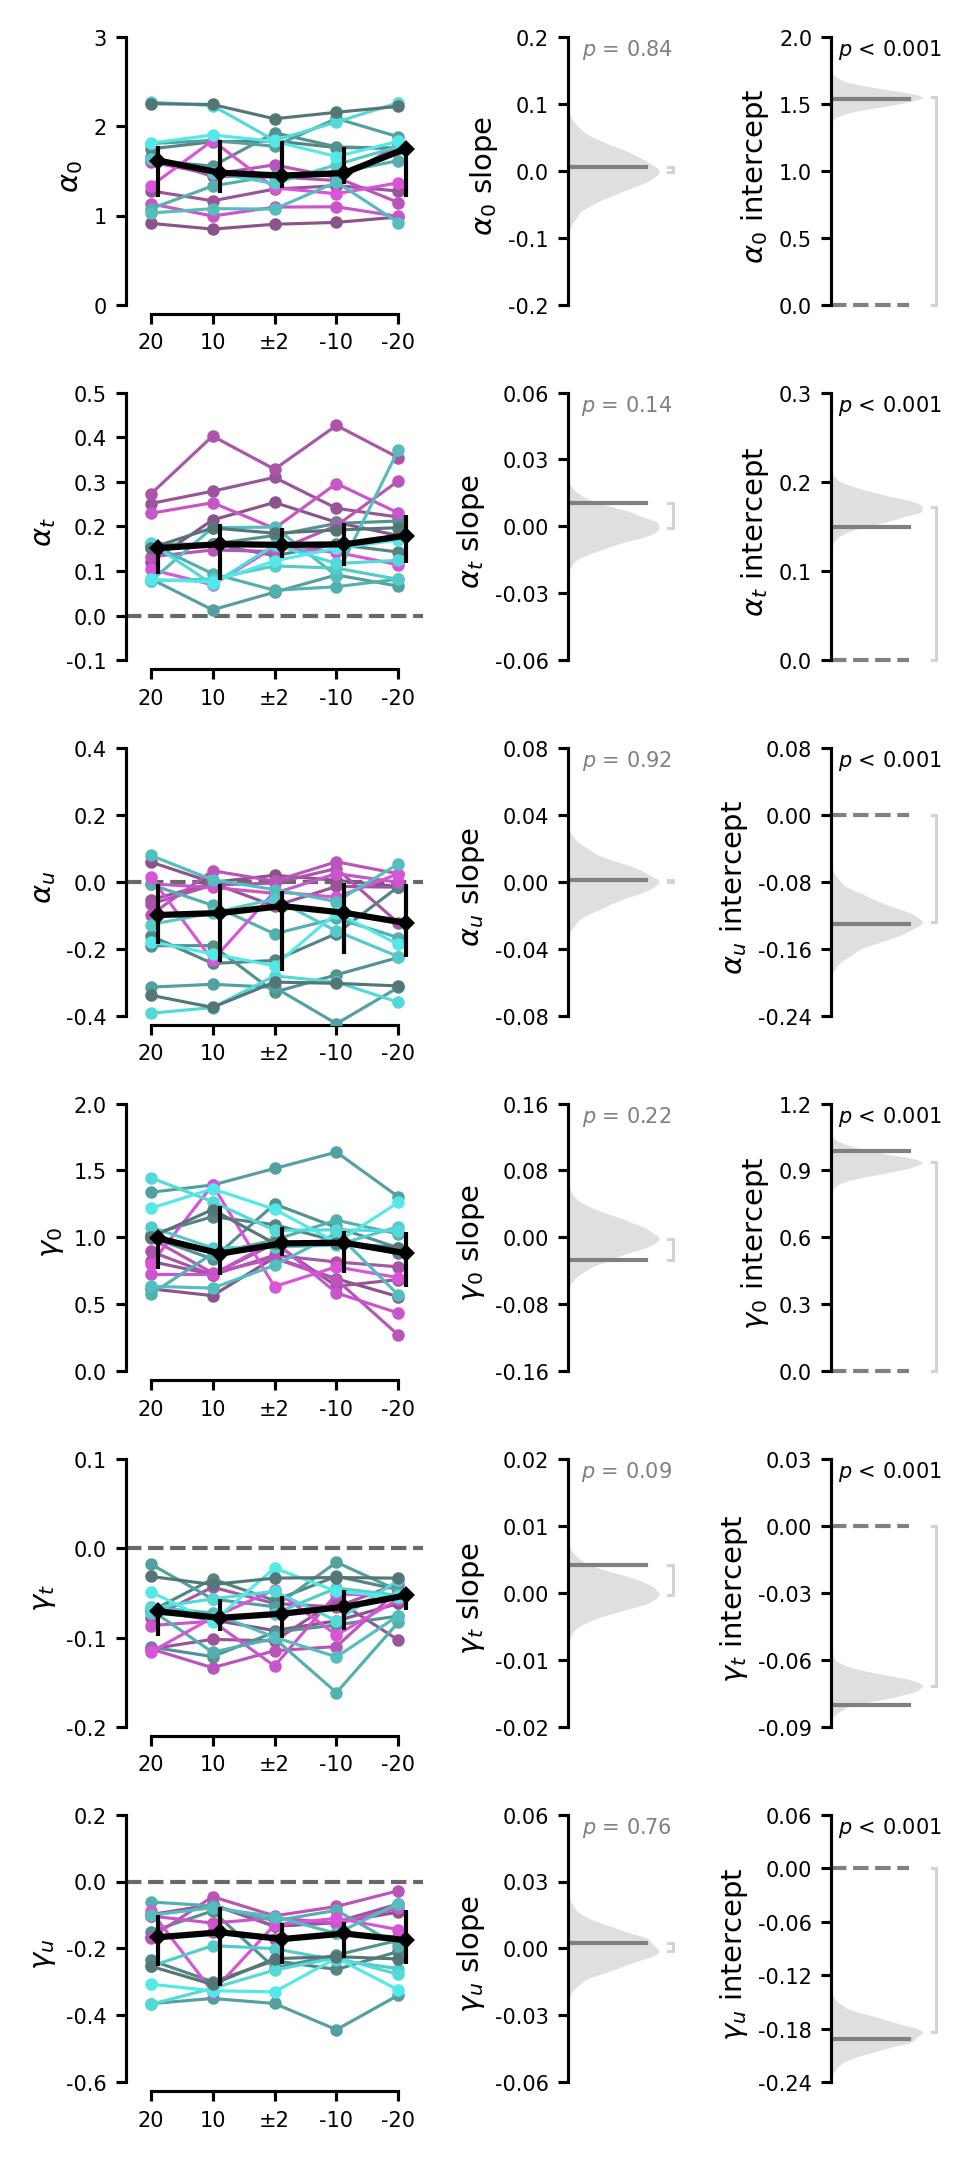

In [6]:
def Figure3E_zero(ax=None, show_xlabel=False):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

    for animal in animalList:
        ax.plot([0, 1, 2, 3, 4], [alpha_0[animal]["20"], alpha_0[animal]["10"], 
                                  alpha_0[animal]["2"], alpha_0[animal]["rev10"], 
                                  alpha_0[animal]["rev20"]], 
                        color=rat_markers[animal][0], marker=rat_markers[animal][1], lw=.75,
                        markersize=2, linestyle=rat_markers[animal][2], label='Individuals', zorder=8 if animal=='RatM00' else 5)
        
    ax.set_xlim(0, 4)
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_xticklabels(["20", "10", "±2", "-10", "-20"])
    _ = r'$v_{belt}$'
    if show_xlabel:
        ax.set_xlabel(f'{_} (cm/s)')

    ax.set_ylim(0, 3)
    ax.set_yticks([0, 1, 2, 3])
    ax.set_ylabel(r'$\alpha_0$')

    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(alpha_0, ax=ax, dist_or_tm='tm', animalList=animalList, err='percentile')

def Figure3E_t(ax=None, show_xlabel=False):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

    for animal in animalList:
        ax.plot([0, 1, 2, 3, 4], [alpha_t[animal]["20"], alpha_t[animal]["10"], alpha_t[animal]["2"], alpha_t[animal]["rev10"], alpha_t[animal]["rev20"]], 
                        color=rat_markers[animal][0], label=animal, marker=rat_markers[animal][1], lw=.75,
                        markersize=2, linestyle=rat_markers[animal][2], zorder=8 if animal=='RatM00' else 5)

    ax.set_xlim(0, 4)
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_xticklabels(["20", "10", "±2", "-10", "-20"])
    _ = r'$v_{belt}$'
    if show_xlabel:
        ax.set_xlabel(f'{_} (cm/s)')

    ax.set_ylim(-0.1, .5)
    ax.set_yticks([-0.1, 0, .1, .2, .3, .4, .5])
    ax.set_ylabel(r'$\alpha_t$')
    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0)

    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(alpha_t, ax=ax, dist_or_tm='tm', animalList=animalList, err='percentile')

def Figure3E_u(ax=None, show_xlabel=False):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

    for animal in animalList:
        ax.plot([0, 1, 2, 3, 4], [alpha_u[animal]["20"], alpha_u[animal]["10"], alpha_u[animal]["2"], alpha_u[animal]["rev10"], alpha_u[animal]["rev20"]], 
                        color=rat_markers[animal][0], label=animal, marker=rat_markers[animal][1], lw=.75,
                        markersize=2, linestyle=rat_markers[animal][2], zorder=8 if animal=='RatM00' else 5)
        
    ax.set_xlim(0, 4)
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_xticklabels(["20", "10", "±2", "-10", "-20"])
    _ = r'$v_{belt}$'
    if show_xlabel:
        ax.set_xlabel(f'{_} (cm/s)')

    ax.set_ylim(-0.4, .4)
    ax.set_yticks([-0.4, -0.2, 0, 0.2, 0.4])
    ax.set_ylabel(r'$\alpha_u$')

    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0)
    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(alpha_u, ax=ax, dist_or_tm='tm', animalList=animalList, err='percentile')

def Figure3F_zero(ax=None, show_xlabel=False):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

    for animal in animalList:
        ax.plot([0, 1, 2, 3, 4], [gamma_0[animal]["20"], gamma_0[animal]["10"], gamma_0[animal]["2"], gamma_0[animal]["rev10"], gamma_0[animal]["rev20"]], 
                        color=rat_markers[animal][0], marker=rat_markers[animal][1], lw=.75,
                        markersize=2, linestyle=rat_markers[animal][2], label='Individuals', zorder=8 if animal=='RatM00' else 5)

    ax.set_xlim(0, 4)
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_xticklabels(["20", "10", "±2", "-10", "-20"])
    _ = r'$v_{belt}$'
    if show_xlabel:
        ax.set_xlabel(f'{_} (cm/s)')

    ax.set_ylim(0, 2)
    ax.set_yticks([0, 0.5, 1, 1.5, 2])
    ax.set_ylabel(r'$\gamma_0$')
    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(gamma_0, ax=ax, dist_or_tm='tm', animalList=animalList, err='percentile')

def Figure3F_t(ax=None, show_xlabel=False):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

    for animal in animalList:
        ax.plot([0, 1, 2, 3, 4], [gamma_t[animal]["20"], gamma_t[animal]["10"], gamma_t[animal]["2"], gamma_t[animal]["rev10"], gamma_t[animal]["rev20"]], 
                        color=rat_markers[animal][0], label=animal, marker=rat_markers[animal][1], lw=.75,
                        markersize=2, linestyle=rat_markers[animal][2], zorder=8 if animal=='RatM00' else 5)

    ax.set_xlim(0, 4)
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_xticklabels(["20", "10", "±2", "-10", "-20"])
    _ = r'$v_{belt}$'
    if show_xlabel:
        ax.set_xlabel(f'{_} (cm/s)')

    ax.set_ylim(-0.2, 0.1)
    ax.set_yticks([-0.2, -.1, 0, 0.1])
    ax.set_ylabel(r'$\gamma_t$')
    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0)
    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(gamma_t, ax=ax, dist_or_tm='tm', animalList=animalList, err='percentile')

def Figure3F_u(ax=None, show_xlabel=False):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

    for animal in animalList:
        ax.plot([0, 1, 2, 3, 4], [gamma_u[animal]["20"], gamma_u[animal]["10"], gamma_u[animal]["2"], gamma_u[animal]["rev10"], gamma_u[animal]["rev20"]], 
                        color=rat_markers[animal][0], label=animal, marker=rat_markers[animal][1], lw=.75,
                        markersize=2, linestyle=rat_markers[animal][2], zorder=8 if animal=='RatM00' else 5)
        
    ax.set_xlim(0, 4)
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_xticklabels(["20", "10", "±2", "-10", "-20"])
    _ = r'$v_{belt}$'
    if show_xlabel:
        ax.set_xlabel(f'{_} (cm/s)')

    ax.set_ylim(-0.6, 0.2)
    ax.set_yticks([-.6, -.4, -.2, 0, .2])
    ax.set_ylabel(r'$\gamma_u$')
    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0)
    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(gamma_u, ax=ax, dist_or_tm='tm', animalList=animalList, err='percentile')


def Figure3E_zero_stats(ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))
    alpha_0, _, _, _, _, _, _, _, _, _, _, _ = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
    regression_permutation(alpha_0, dist_or_tm='tm', varname=r'$\alpha_0$', 
                        ax_slope=ax_slope, yticks_slope=[-0.2, -0.1, 0, 0.1, 0.2], 
                        ax_intercept=ax_intercept, y_ticks_intercept=[0, .5, 1, 1.5, 2])

def Figure3E_t_stats(ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))
    _, alpha_t, _, _, _, _, _, _, _, _, _, _ = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
    regression_permutation(alpha_t, dist_or_tm='tm', varname=r'$\alpha_t$', 
                        ax_slope=ax_slope, yticks_slope=[-.06, -.03, 0, .03, .06], 
                        ax_intercept=ax_intercept, y_ticks_intercept=[0, .1, .2, .3])

def Figure3E_u_stats(ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))
    _, _, alpha_u, _, _, _, _, _, _, _, _, _ = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
    regression_permutation(alpha_u, dist_or_tm='tm', varname=r'$\alpha_u$',
                        ax_slope=ax_slope, yticks_slope=[-.08, -.04, 0, .04, .08],
                        ax_intercept=ax_intercept, y_ticks_intercept=[-.24, -.16, -.08, 0, .08],)

def Figure3F_zero_stats(ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))
    _, _, _, gamma_0, _, _, _, _, _, _, _, _ = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
    regression_permutation(gamma_0, dist_or_tm='tm', varname=r'$\gamma_0$',
                        ax_slope=ax_slope, yticks_slope=[-.16, -.08, 0, .08, .16],
                        ax_intercept=ax_intercept, y_ticks_intercept=[0, .3, .6, .9, 1.2])

def Figure3F_t_stats(ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))
    _, _, _, _, gamma_t, _, _, _, _, _, _, _ = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
    regression_permutation(gamma_t, dist_or_tm='tm', varname=r'$\gamma_t$',
                        ax_slope=ax_slope, yticks_slope=[-.02, -.01, 0, .01, .02],
                        ax_intercept=ax_intercept, y_ticks_intercept=[-.09, -.06, -.03, 0, 0.03])

def Figure3F_u_stats(ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))
    _, _, _, _, _, gamma_u, _, _, _, _, _, _ = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
    regression_permutation(gamma_u, dist_or_tm='tm', varname=r'$\gamma_u$',
                        ax_slope=ax_slope, yticks_slope=[-.06, -.03, 0, .03, .06],
                        ax_intercept=ax_intercept, y_ticks_intercept=[-.24, -.18, -.12, -0.06, 0, 0.06])

fig, axs = plt.subplots(6, 3, figsize=(cm2inch(8), cm2inch(18)), gridspec_kw={'width_ratios': [2.5, 1, 1]})
Figure3E_zero(axs[0, 0])
Figure3E_t(axs[1, 0])
Figure3E_u(axs[2, 0])
Figure3F_zero(axs[3, 0])
Figure3F_t(axs[4, 0])
Figure3F_u(axs[5, 0])

Figure3E_zero_stats(ax_slope=axs[0, 1], ax_intercept=axs[0, 2])
Figure3E_t_stats(ax_slope=axs[1, 1], ax_intercept=axs[1, 2])
Figure3E_u_stats(ax_slope=axs[2, 1], ax_intercept=axs[2, 2])
Figure3F_zero_stats(ax_slope=axs[3, 1], ax_intercept=axs[3, 2])
Figure3F_t_stats(ax_slope=axs[4, 1], ax_intercept=axs[4, 2])
Figure3F_u_stats(ax_slope=axs[5, 1], ax_intercept=axs[5, 2])

# Figure 3: Dynamics of decision parameters across action costs.

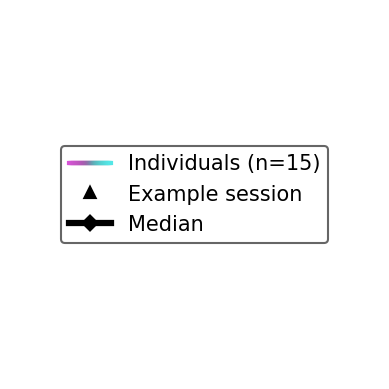

In [7]:

def dummy_legend(ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    ex_session = ax.plot(2, 0, color='black', marker='^', zorder=10, markersize=2, linewidth=0, label='Example session')
    median = ax.plot([-100, -101], [-100, -101], color='k', marker='D', markersize=2, linestyle='-', lw=1.5, label=f'Median', zorder=5)

    ax.axis('off')
    ax.set_xlim(10, 11)
    ax.set_ylim(10, 11)

    add_colored_intact(ax, handles=[ex_session, median],
                    labels=['Example session', 'Median'], text=f'Individuals (n={len(animalList)})', 
                    loc='center', bbox=(.5, .5))


fig, axs = plt.subplots(1, 1, figsize=(cm2inch(3), cm2inch(3)))
dummy_legend(ax=axs)

In [ ]:

fig = plt.figure(figsize=(cm2inch(18), cm2inch(18.5)),
                 constrained_layout=True, facecolor='w', dpi=600)

gs0 = fig.add_gridspec(8, 1, height_ratios=[1.2, 1, 1, 1, .1, 1, 1, 1])

row1 = gs0[0].subgridspec(1, 3, wspace=.5, hspace=.5, width_ratios=[1, .2, 1])
distance_schematic = plt.subplot(row1[0])
vbelt_schematic = plt.subplot(row1[2])

row2 = gs0[1].subgridspec(1, 7, wspace=.5, hspace=.5, width_ratios=[2.5, 1, 1, .1, 2.5, 1, 1])
fit_alpha_0_distance = plt.subplot(row2[0])
fit_alpha_0_distance_slope = plt.subplot(row2[1])
fit_alpha_0_distance_intercept = plt.subplot(row2[2])
fit_alpha_0_vbelt = plt.subplot(row2[4])
fit_alpha_0_vbelt_slope = plt.subplot(row2[5])
fit_alpha_0_vbelt_intercept = plt.subplot(row2[6])

row3 = gs0[2].subgridspec(1, 7, wspace=.5, hspace=.5, width_ratios=[2.5, 1, 1, .1, 2.5, 1, 1])
fit_alpha_t_distance = plt.subplot(row3[0])
fit_alpha_t_distance_slope = plt.subplot(row3[1])
fit_alpha_t_distance_intercept = plt.subplot(row3[2])
fit_alpha_t_vbelt = plt.subplot(row3[4])
fit_alpha_t_vbelt_slope = plt.subplot(row3[5])
fit_alpha_t_vbelt_intercept = plt.subplot(row3[6])

row4 = gs0[3].subgridspec(1, 7, wspace=.5, hspace=.5, width_ratios=[2.5, 1, 1, .1, 2.5, 1, 1])
fit_alpha_u_distance = plt.subplot(row4[0])
fit_alpha_u_distance_slope = plt.subplot(row4[1])
fit_alpha_u_distance_intercept = plt.subplot(row4[2])
fit_alpha_u_vbelt = plt.subplot(row4[4])
fit_alpha_u_vbelt_slope = plt.subplot(row4[5])
fit_alpha_u_vbelt_intercept = plt.subplot(row4[6])

row5 = gs0[5].subgridspec(1, 7, wspace=.5, hspace=.5, width_ratios=[2.5, 1, 1, .1, 2.5, 1, 1])
fit_gamma_0_distance = plt.subplot(row5[0])
fit_gamma_0_distance_slope = plt.subplot(row5[1])
fit_gamma_0_distance_intercept = plt.subplot(row5[2])
fit_gamma_0_vbelt = plt.subplot(row5[4])
fit_gamma_0_vbelt_slope = plt.subplot(row5[5])
fit_gamma_0_vbelt_intercept = plt.subplot(row5[6])

row6 = gs0[6].subgridspec(1, 7, wspace=.5, hspace=.5, width_ratios=[2.5, 1, 1, .1, 2.5, 1, 1])
fit_gamma_t_distance = plt.subplot(row6[0])
fit_gamma_t_distance_slope = plt.subplot(row6[1])
fit_gamma_t_distance_intercept = plt.subplot(row6[2])
fit_gamma_t_vbelt = plt.subplot(row6[4])
fit_gamma_t_vbelt_slope = plt.subplot(row6[5])
fit_gamma_t_vbelt_intercept = plt.subplot(row6[6])

row7 = gs0[7].subgridspec(1, 7, wspace=.5, hspace=.5, width_ratios=[2.5, 1, 1, .1, 2.5, 1, 1])
fit_gamma_u_distance = plt.subplot(row7[0])
fit_gamma_u_distance_slope = plt.subplot(row7[1])
fit_gamma_u_distance_intercept = plt.subplot(row7[2])
fit_gamma_u_vbelt = plt.subplot(row7[4])
fit_gamma_u_vbelt_slope = plt.subplot(row7[5])
fit_gamma_u_vbelt_intercept = plt.subplot(row7[6])




Figure3A(ax=distance_schematic)
Figure3D(ax=vbelt_schematic)

Figure3B_zero(ax=fit_alpha_0_distance)
Figure3B_t(ax=fit_alpha_t_distance)
Figure3B_u(ax=fit_alpha_u_distance, show_xlabel=True)
Figure3C_zero(ax=fit_gamma_0_distance)
Figure3C_t(ax=fit_gamma_t_distance)
Figure3C_u(ax=fit_gamma_u_distance, show_xlabel=True)

Figure3B_zero_stats(ax_slope=fit_alpha_0_distance_slope, ax_intercept=fit_alpha_0_distance_intercept)
Figure3B_t_stats(ax_slope=fit_alpha_t_distance_slope, ax_intercept=fit_alpha_t_distance_intercept)
Figure3B_u_stats(ax_slope=fit_alpha_u_distance_slope, ax_intercept=fit_alpha_u_distance_intercept)
Figure3C_zero_stats(ax_slope=fit_gamma_0_distance_slope, ax_intercept=fit_gamma_0_distance_intercept)
Figure3C_t_stats(ax_slope=fit_gamma_t_distance_slope, ax_intercept=fit_gamma_t_distance_intercept)
Figure3C_u_stats(ax_slope=fit_gamma_u_distance_slope, ax_intercept=fit_gamma_u_distance_intercept)


Figure3E_zero(ax=fit_alpha_0_vbelt)
Figure3E_t(ax=fit_alpha_t_vbelt)
Figure3E_u(ax=fit_alpha_u_vbelt, show_xlabel=True)
Figure3F_zero(ax=fit_gamma_0_vbelt)
Figure3F_t(ax=fit_gamma_t_vbelt)
Figure3F_u(ax=fit_gamma_u_vbelt, show_xlabel=True)

Figure3E_zero_stats(ax_slope=fit_alpha_0_vbelt_slope, ax_intercept=fit_alpha_0_vbelt_intercept)
Figure3E_t_stats(ax_slope=fit_alpha_t_vbelt_slope, ax_intercept=fit_alpha_t_vbelt_intercept)
Figure3E_u_stats(ax_slope=fit_alpha_u_vbelt_slope, ax_intercept=fit_alpha_u_vbelt_intercept)
Figure3F_zero_stats(ax_slope=fit_gamma_0_vbelt_slope, ax_intercept=fit_gamma_0_vbelt_intercept)
Figure3F_t_stats(ax_slope=fit_gamma_t_vbelt_slope, ax_intercept=fit_gamma_t_vbelt_intercept)
Figure3F_u_stats(ax_slope=fit_gamma_u_vbelt_slope, ax_intercept=fit_gamma_u_vbelt_intercept)

axes = fig.get_axes()
for ax in axes:
    ax.yaxis.set_major_formatter('{x:>5.2f}')


legend = fig.add_axes([.5, .92, .01, .01])
dummy_legend(ax=legend)

figuresLabels={"A":[0.105, .96], "D":[0.65, .96], 
               "B":[0.0, .835], "E":[0.515, .835],
               "C":[0.0, .415], "F":[0.515, .415],
               }

for label,coordinates in sorted(figuresLabels.items()):
    fig.text(coordinates[0], coordinates[1],
             label, figure=fig, 
             weight='bold', fontsize=7, ha='left', va='bottom')

plt.savefig("./Figures_paper/Figure_3.pdf", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)
plt.savefig("./Figures_paper/Figure_3.svg", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="svg", dpi=600)

$\alpha_0$: p_s=0.896, p_i=0.000, obs_slope=0.008, obs_intercept=1.153
$\alpha_t$: p_s=0.106, p_i=0.000, obs_slope=-0.022, obs_intercept=0.194
$\alpha_u$: p_s=0.425, p_i=0.580, obs_slope=0.017, obs_intercept=-0.013
$\gamma_0$: p_s=0.839, p_i=0.000, obs_slope=-0.011, obs_intercept=0.739
